In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eigh
from tqdm import tqdm
import sys
import os
import sympy as sp


# Add the parent directory to the path to import nmrkan modules
if os.path.abspath(os.path.join(os.getcwd(), '..')) not in sys.path:
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import the Hamiltonian function
from data_generation.nmr_datagen import ham_reduced_symmetric

# Import training components from the unified framework
from nmrkan import KharKAN, SingleOutputTrainer, TrainingConfig, ModelConfig
import torch
from torch.utils.data import DataLoader, TensorDataset
from nmrkan.analysis import FormulaExtractor

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("viridis")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Helper to keep eigenvalues consistently ordered across sign flips
def sort_eigenvalues_with_flip(eigenvals, ratio_value=None, force_flip=False):
    ordered = np.sort(eigenvals)
    should_flip = force_flip or (ratio_value is not None and ratio_value < 0)
    if should_flip:
        ordered[[0, 2]] = ordered[[2, 0]]
    return ordered

In [3]:
# Define 2D parameter generation function
def generate_2d_normalized_dataset(n_samples=5000, 
                                 deltajam_ratio_range=(-2.0, 2.0), 
                                 deltajmx_ratio_range=(-2.0, 2.0)):
    """
    Generate normalized 2D dataset using ham_reduced_symmetric.
    
    Directly generates ratios (DeltaJAM/Jintra, DeltaJMX/Jintra) uniformly,
    then calls ham_reduced_symmetric(1, 1, 1, ratio1, ratio2, 0).
    
    Parameters:
    - deltajam_ratio_range: Range for DeltaJAM/Jintra ratio
    - deltajmx_ratio_range: Range for DeltaJMX/Jintra ratio
    
    Returns normalized inputs (DeltaJAM/Jintra, DeltaJMX/Jintra) and normalized eigenvalues
    """
    
    # Generate random ratios directly (uniformly distributed)
    np.random.seed(42)  # For reproducibility
    deltajam_ratios = np.random.uniform(deltajam_ratio_range[0], deltajam_ratio_range[1], n_samples)
    deltajmx_ratios = np.random.uniform(deltajmx_ratio_range[0], deltajmx_ratio_range[1], n_samples)
    
    # Initialize output arrays
    inputs_normalized = np.zeros((n_samples, 2))
    eigenvals_normalized = np.zeros((n_samples, 4))  # 4x4 Hamiltonian has 4 eigenvalues
    
    successful_samples = 0
    
    for i in tqdm(range(n_samples), desc="Generating 2D dataset"):
        try:
            # Use ratios directly
            deltajam_ratio = deltajam_ratios[i]
            deltajmx_ratio = deltajmx_ratios[i]
            
            # Create Hamiltonian: ham_reduced_symmetric(JAA, JMM, JXX, dJAM, dJMX, dJAX)
            # We use: JAA=JMM=JXX=1 (normalized), dJAM=deltajam_ratio, dJMX=deltajmx_ratio, dJAX=0
            H = ham_reduced_symmetric(1.0, 1.0, 1.0, deltajam_ratio, deltajmx_ratio, 0.0)
            
            # Calculate eigenvalues (already normalized since Jintra=1)
            eigenvals, _ = eigh(H)
            eigenvals = sort_eigenvalues_with_flip(eigenvals, ratio_value=deltajam_ratio*0+1)
            
            # Store inputs (ratios)
            inputs_normalized[successful_samples, 0] = deltajam_ratio
            inputs_normalized[successful_samples, 1] = deltajmx_ratio
            
            # Store eigenvalues (already normalized)
            eigenvals_normalized[successful_samples, :] = eigenvals
            
            successful_samples += 1
            
        except Exception as e:
            continue
    
    # Trim arrays to successful samples
    inputs_final = inputs_normalized[:successful_samples]
    eigenvals_final = eigenvals_normalized[:successful_samples]
    
    return inputs_final, eigenvals_final

# Generate the dataset
print("Generating 2D normalized dataset...")
X, y = generate_2d_normalized_dataset(10000)

print(f"Dataset generated successfully!")
print(f"Input shape: {X.shape} (DeltaJAM/Jintra, DeltaJMX/Jintra)")
print(f"Output shape: {y.shape} (4 normalized eigenvalues)")
print(f"Input ranges:")
print(f"  DeltaJAM/Jintra: [{X[:, 0].min():.3f}, {X[:, 0].max():.3f}]")
print(f"  DeltaJMX/Jintra: [{X[:, 1].min():.3f}, {X[:, 1].max():.3f}]")
print(f"Eigenvalue ranges:")
for i in range(4):
    print(f"  Eigenvalue {i+1}/Jintra: [{y[:, i].min():.3f}, {y[:, i].max():.3f}]")

Generating 2D normalized dataset...


Generating 2D dataset: 100%|██████████| 10000/10000 [00:00<00:00, 57298.14it/s]

Dataset generated successfully!
Input shape: (10000, 2) (DeltaJAM/Jintra, DeltaJMX/Jintra)
Output shape: (10000, 4) (4 normalized eigenvalues)
Input ranges:
  DeltaJAM/Jintra: [-2.000, 1.999]
  DeltaJMX/Jintra: [-1.999, 2.000]
Eigenvalue ranges:
  Eigenvalue 1/Jintra: [-2.933, -1.259]
  Eigenvalue 2/Jintra: [-1.663, -1.250]
  Eigenvalue 3/Jintra: [-1.241, -0.251]
  Eigenvalue 4/Jintra: [0.750, 1.631]


Computing eigenvalue surfaces on regular grid...


Grid rows: 100%|██████████| 50/50 [00:00<00:00, 1051.21it/s]


Surface computation completed!


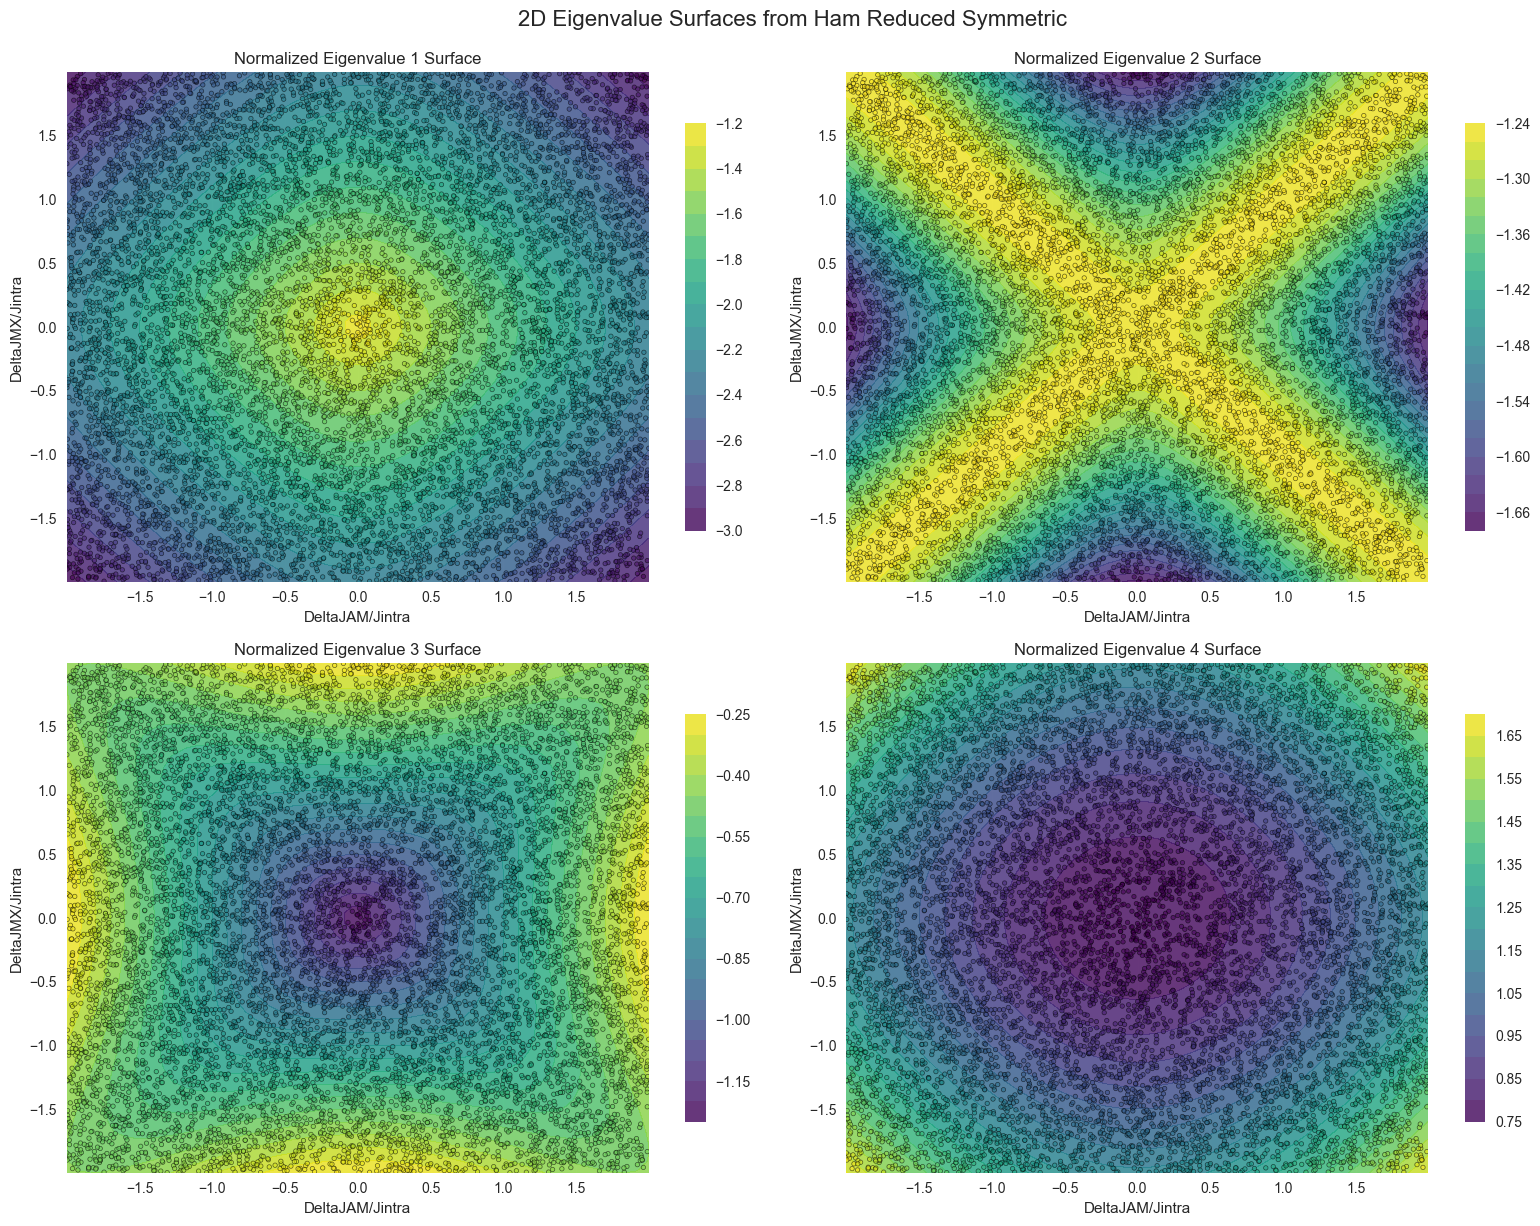

In [4]:
# Create 2D surface plots for all 4 eigenvalues
# First, create a regular grid for surface visualization
n_grid = 50
x1_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
x2_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

# Calculate eigenvalues on the grid
eigenval_surfaces = np.zeros((n_grid, n_grid, 4))

print("Computing eigenvalue surfaces on regular grid...")
for i in tqdm(range(n_grid), desc="Grid rows"):
    for j in range(n_grid):
        try:
            # Use ratios directly from grid
            deltajam_ratio = X1_grid[i, j]
            deltajmx_ratio = X2_grid[i, j]
            
            H = ham_reduced_symmetric(1.0, 1.0, 1.0, deltajam_ratio, deltajmx_ratio, 0.0)
            eigenvals, _ = eigh(H)
            eigenvals = sort_eigenvalues_with_flip(eigenvals, ratio_value=deltajam_ratio*0+1)
            
            eigenval_surfaces[i, j, :] = eigenvals
        except:
            eigenval_surfaces[i, j, :] = np.nan

print("Surface computation completed!")

# Plot 2D surfaces
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i in range(4):
    # Create contour plot
    im = axes[i].contourf(X1_grid, X2_grid, eigenval_surfaces[:, :, i], 
                         levels=20, cmap='viridis', alpha=0.8)
    
    # Overlay scatter points from dataset
    scatter = axes[i].scatter(X[:, 0], X[:, 1], c=y[:, i], 
                             cmap='viridis', s=10, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    axes[i].set_xlabel('DeltaJAM/Jintra')
    axes[i].set_ylabel('DeltaJMX/Jintra')
    axes[i].set_title(f'Normalized Eigenvalue {i+1} Surface')
    axes[i].grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.suptitle('2D Eigenvalue Surfaces from Ham Reduced Symmetric', fontsize=16, y=1.02)
plt.show()

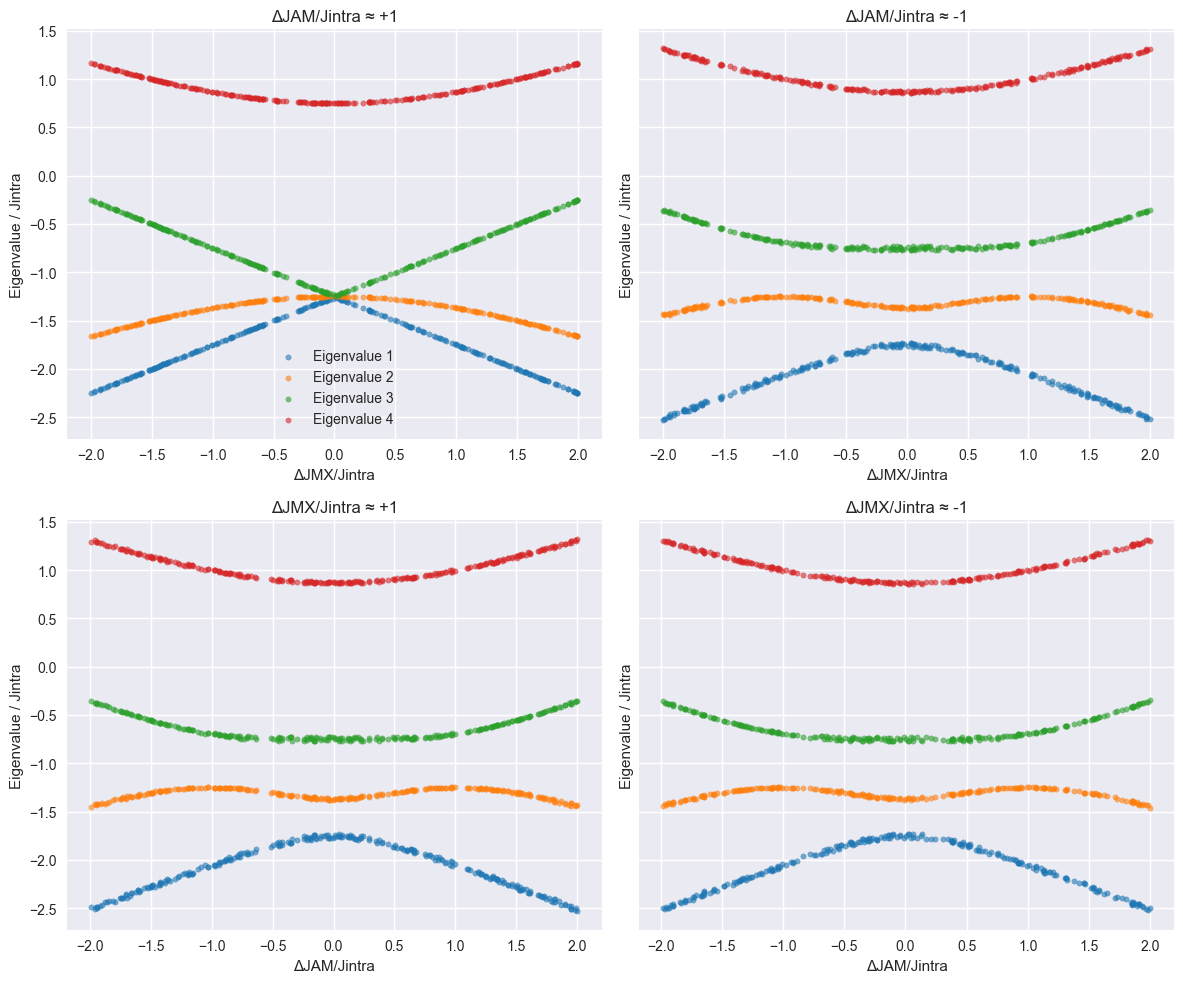

In [5]:
# Cross sections at ratio1 = ±1 and ratio2 = ±1
ratio1, ratio2 = X[:, 0], X[:, 1]
eigenvals0, eigenvals1, eigenvals2, eigenvals3 = y.T
tolerance = 0.05

slices = [
    ("ΔJAM/Jintra ≈ +1", np.abs(ratio1 - 0.0) < tolerance, ratio2, "ΔJMX/Jintra"),
    ("ΔJAM/Jintra ≈ -1", np.abs(ratio1 + 1.0) < tolerance, ratio2, "ΔJMX/Jintra"),
    ("ΔJMX/Jintra ≈ +1", np.abs(ratio2 - 1.0) < tolerance, ratio1, "ΔJAM/Jintra"),
    ("ΔJMX/Jintra ≈ -1", np.abs(ratio2 + 1.0) < tolerance, ratio1, "ΔJAM/Jintra"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
labels = ['Eigenvalue 1', 'Eigenvalue 2', 'Eigenvalue 3', 'Eigenvalue 4']
eigenvals = [eigenvals0, eigenvals1, eigenvals2, eigenvals3]

for ax, (title, mask, x_vals, xlabel) in zip(axes, slices):
    for ev, color, label in zip(eigenvals, colors, labels):
        ax.scatter(x_vals[mask], ev[mask], s=15, alpha=0.6, color=color, label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Eigenvalue / Jintra')
    if ax is axes[0]:
        ax.legend()

plt.tight_layout()
plt.show()

# Train 2D KAN Model

Now we'll train a KAN model with 2 inputs (DeltaJAM/Jintra, DeltaJMX/Jintra) to predict the 4 normalized eigenvalues.

In [6]:
# Prepare data for training
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

print(f"Training data shapes:")
print(f"  Inputs: {X_tensor.shape} (DeltaJAM/Jintra, DeltaJMX/Jintra)")
print(f"  Outputs: {y_tensor.shape} (4 normalized eigenvalues)")

Using device: cuda
Training data shapes:
  Inputs: torch.Size([10000, 2]) (DeltaJAM/Jintra, DeltaJMX/Jintra)
  Outputs: torch.Size([10000, 4]) (4 normalized eigenvalues)


In [ ]:
# Configure the KAN model for 2D input
model_config = ModelConfig(
    layers=(2, 16, 16, 4),  # 4-layer architecture: 2 inputs -> 16 -> 16 -> 4 outputs
    linear_bias=True,
    include_abs=True,
)

# Configure training parameters
training_config = TrainingConfig(
    epochs=1000,  # More epochs for 2D problem
    learning_rate=1e-3,
    batch_size=2048,
    l05_penalty=0.1,
    early_stopping_threshold=1e-6,
    early_stopping_patience=800,
    log_interval=1000
)

print("2D KAN Model Configuration:")
print(f"  Architecture: {model_config.layers}")
print(f"  Training epochs: {training_config.epochs}")
print(f"  Learning rate: {training_config.learning_rate}")
print(f"  Batch size: {training_config.batch_size}")

2D KAN Model Configuration:
  Architecture: (2, 16, 16, 4)
  Training epochs: 1000
  Learning rate: 0.001
  Batch size: 2048


In [8]:
# Create data loaders
dataset_tensor = TensorDataset(X_tensor, y_tensor)
total_size = len(dataset_tensor)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Split dataset
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset_tensor, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=training_config.batch_size, 
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=training_config.batch_size, 
    shuffle=False
)

print(f"Data split:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Number of batches: {len(train_loader)}")

Data split:
  Training samples: 8000
  Validation samples: 2000
  Number of batches: 3


In [9]:
# Initialize and train the 2D KAN model
trainer = SingleOutputTrainer(
    training_config=training_config,
    model_config=model_config,
    device=device,
    experiment_dir=None  # Don't save checkpoints in notebook
)

print("Starting 2D KAN training...")
print("=" * 60)

# Train the model
kan_2d_model = trainer.train(train_loader, val_loader)

print("=" * 60)
print("2D KAN training completed!")

Starting 2D KAN training...
Starting single output training...
Model architecture: (2, 16, 16, 4)
Training on device: cuda


Training:   0%|          | 1/1000 [00:00<06:28,  2.57it/s, Train MSE=2.289244, Val MSE=2.257408, Best Val=2.257408]

Epoch 1: MSE=2.289244, L0.5=24.889716, Total=4.778216


Training: 100%|██████████| 1000/1000 [02:19<00:00,  7.16it/s, Train MSE=0.000321, Val MSE=0.000327, Best Val=0.000327]


Epoch 1000: MSE=0.000321, L0.5=5.075734, Total=0.507894
Training plots saved to: experiment_results\unified_experiments_1766928256\training_curves.png

Training completed! Best validation MSE: 0.000327
Results saved to: experiment_results\unified_experiments_1766928256
2D KAN training completed!


In [10]:
# Evaluate the 2D KAN model
kan_2d_model.eval()

# Generate predictions
with torch.no_grad():
    X_test = X_tensor.to(device)
    y_pred_2d = kan_2d_model(X_test).cpu().numpy()
    y_true_2d = y_tensor.numpy()

# Calculate performance metrics
mse_2d = np.mean((y_pred_2d - y_true_2d)**2)
mae_2d = np.mean(np.abs(y_pred_2d - y_true_2d))
r2_scores_2d = []

for i in range(4):
    # R² score for each eigenvalue
    ss_res = np.sum((y_true_2d[:, i] - y_pred_2d[:, i]) ** 2)
    ss_tot = np.sum((y_true_2d[:, i] - np.mean(y_true_2d[:, i])) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    r2_scores_2d.append(r2)

print("2D KAN Model Performance:")
print(f"  Overall MSE: {mse_2d:.6f}")
print(f"  Overall MAE: {mae_2d:.6f}")
print(f"  Average R²: {np.mean(r2_scores_2d):.4f}")
print("\nPer-eigenvalue R² scores:")
for i, r2 in enumerate(r2_scores_2d):
    print(f"  Eigenvalue {i+1}: {r2:.4f}")

2D KAN Model Performance:
  Overall MSE: 0.000324
  Overall MAE: 0.012347
  Average R²: 0.9878

Per-eigenvalue R² scores:
  Eigenvalue 1: 0.9959
  Eigenvalue 2: 0.9654
  Eigenvalue 3: 0.9902
  Eigenvalue 4: 0.9997


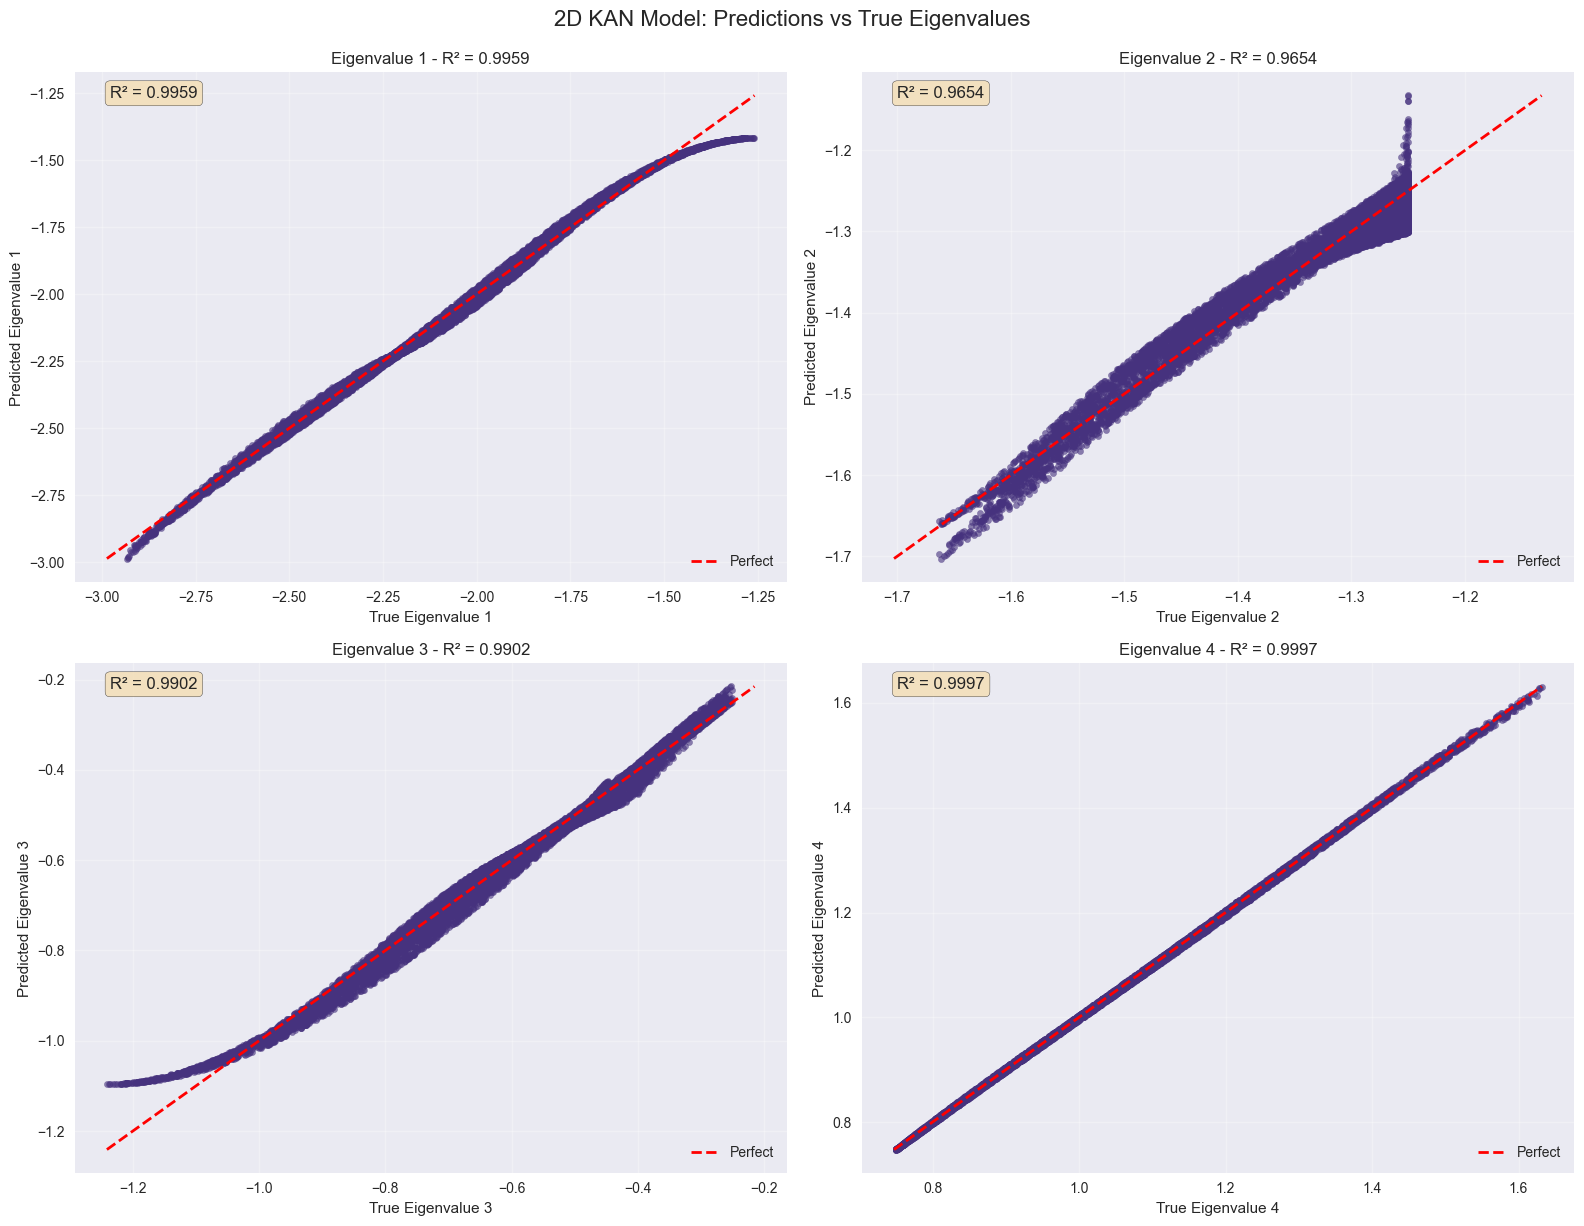

In [11]:
# Visualize 2D KAN model predictions vs true values
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i in range(4):
    # Create scatter plot: predicted vs true
    axes[i].scatter(y_true_2d[:, i], y_pred_2d[:, i], alpha=0.6, s=20)
    
    # Perfect prediction line
    min_val = min(y_true_2d[:, i].min(), y_pred_2d[:, i].min())
    max_val = max(y_true_2d[:, i].max(), y_pred_2d[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
    
    axes[i].set_xlabel(f'True Eigenvalue {i+1}')
    axes[i].set_ylabel(f'Predicted Eigenvalue {i+1}')
    axes[i].set_title(f'Eigenvalue {i+1} - R² = {r2_scores_2d[i]:.4f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()
    
    # Add R² text box
    axes[i].text(0.05, 0.95, f'R² = {r2_scores_2d[i]:.4f}', 
                transform=axes[i].transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.suptitle('2D KAN Model: Predictions vs True Eigenvalues', fontsize=16, y=1.02)
plt.show()

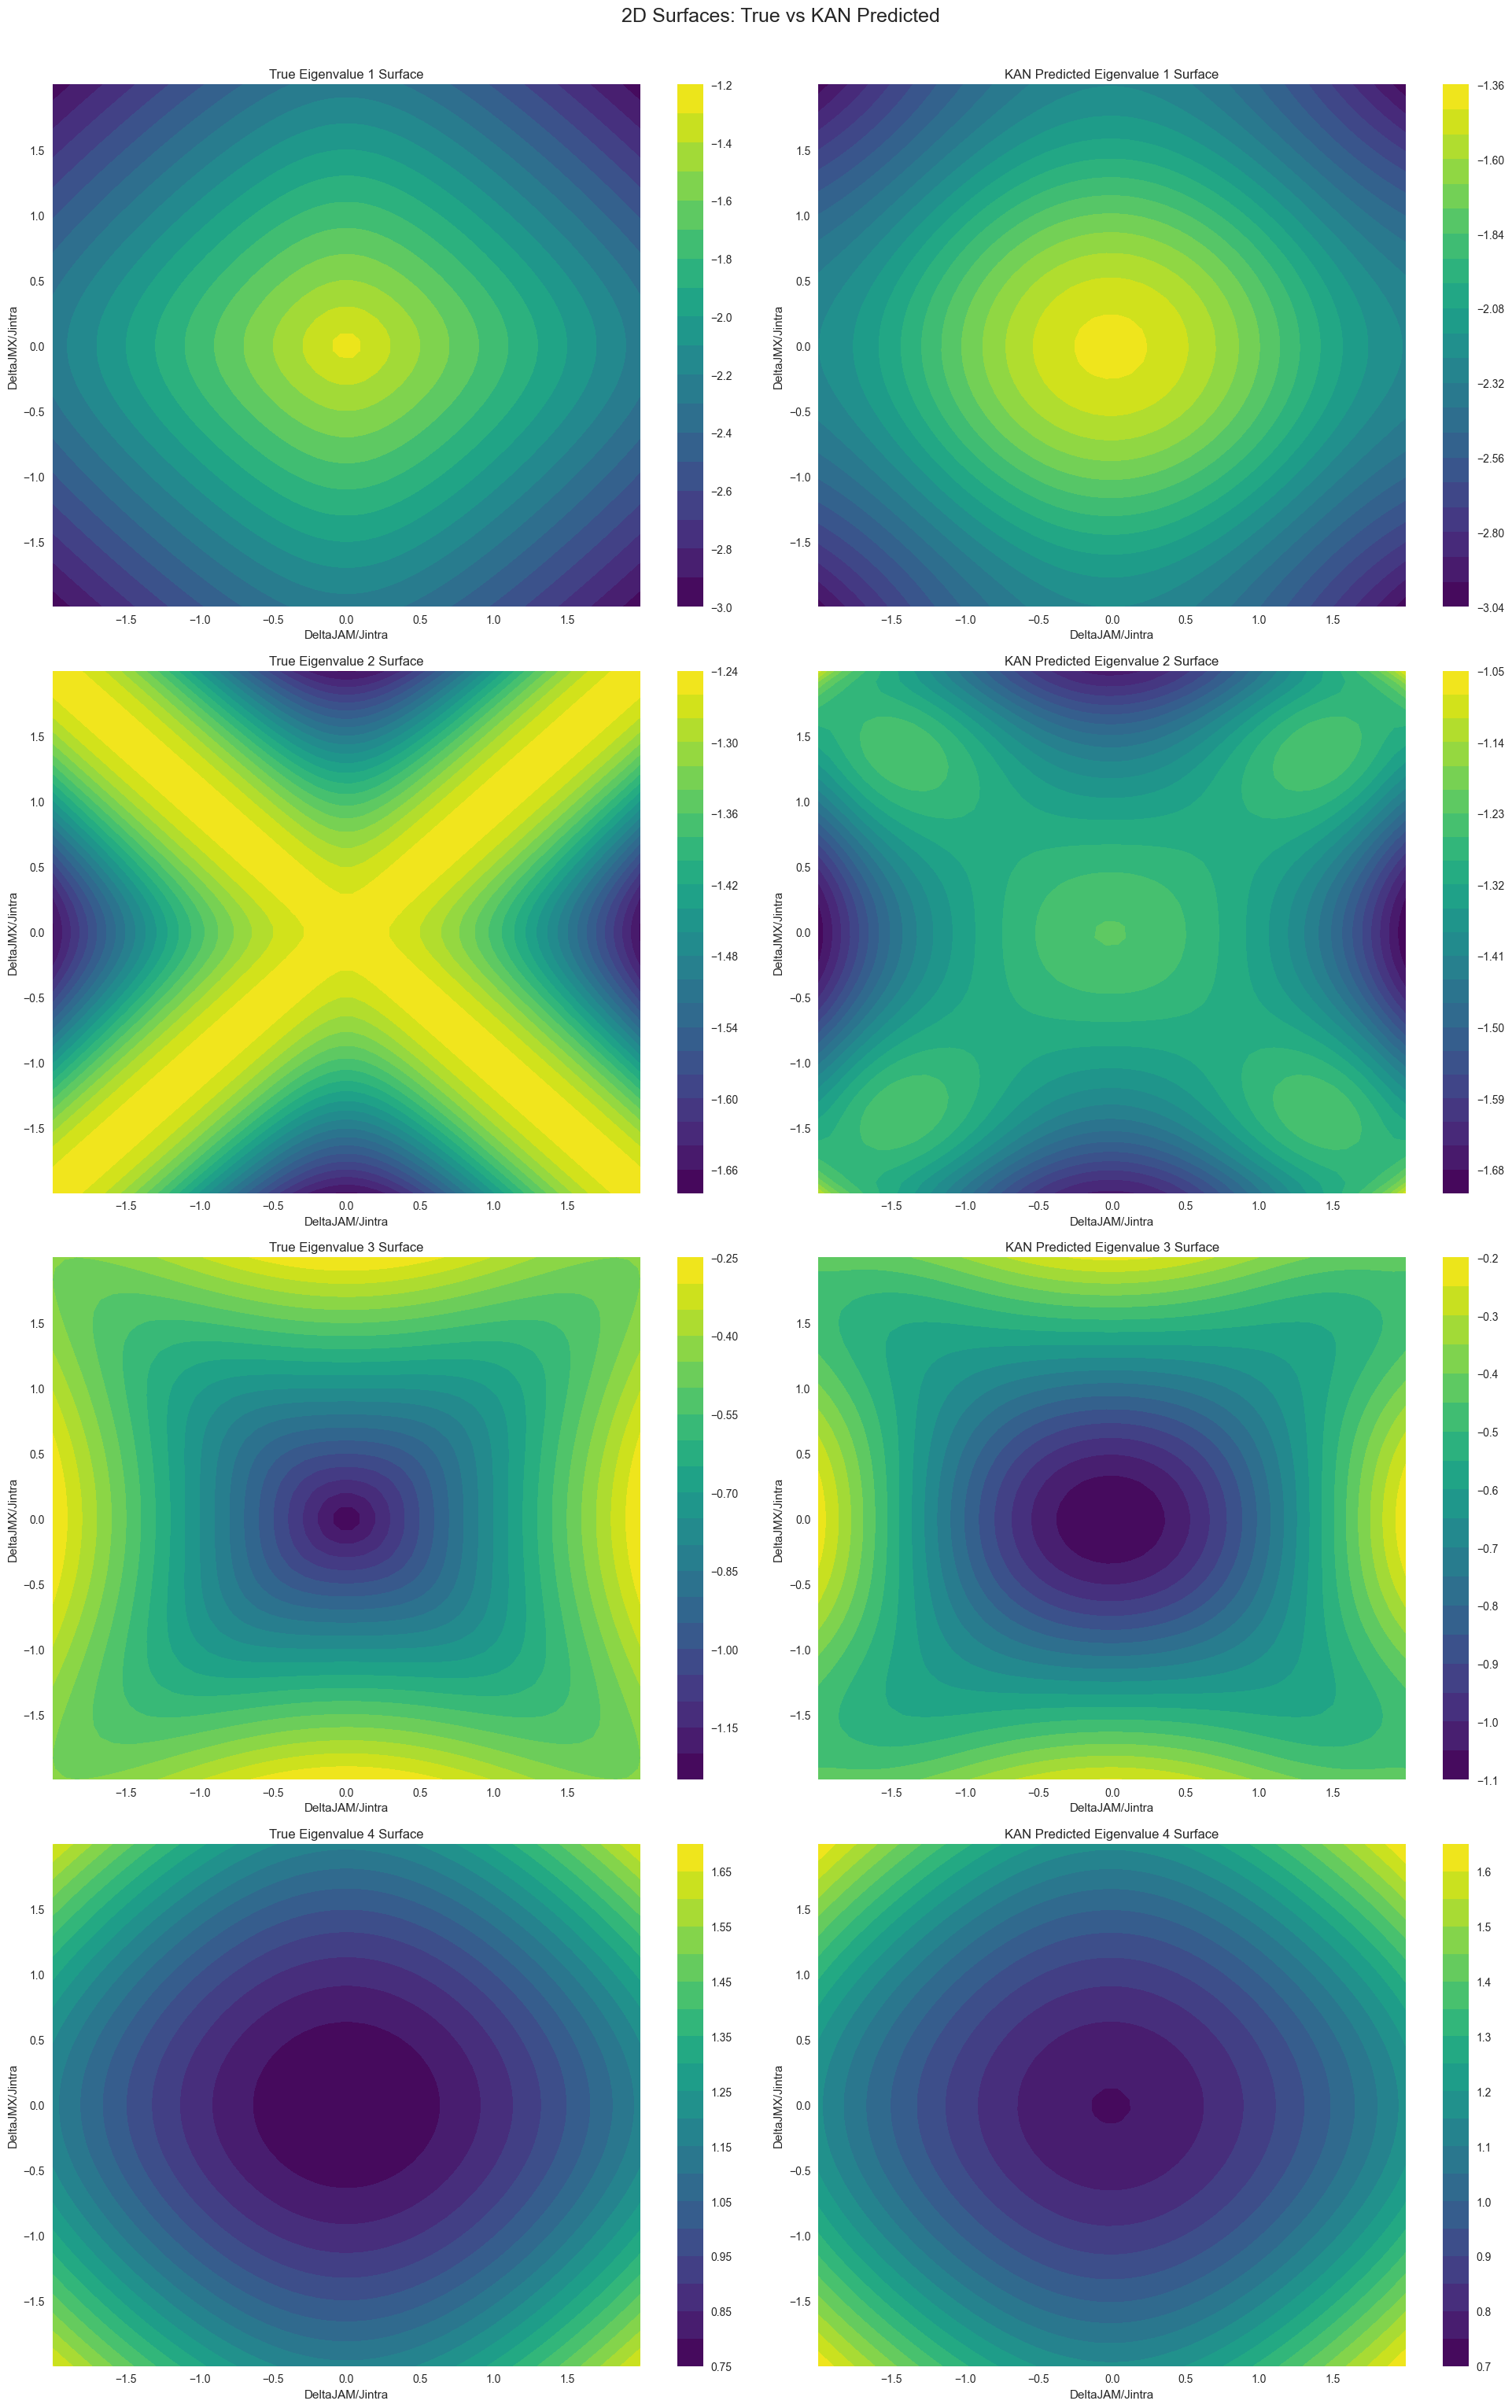

In [12]:
# Visualize prediction surfaces from the 2D KAN model
# Generate predictions on the regular grid
grid_points = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

with torch.no_grad():
    grid_pred = kan_2d_model(grid_tensor).cpu().numpy()

# Reshape predictions to grid format
pred_surfaces = grid_pred.reshape(n_grid, n_grid, 4)

# Plot comparison: True vs Predicted surfaces
fig, axes = plt.subplots(4, 2, figsize=(20, 30))

for i in range(4):
    # True surface
    im1 = axes[i, 0].contourf(X1_grid, X2_grid, eigenval_surfaces[:, :, i], 
                             levels=20, cmap='viridis')
    axes[i, 0].set_title(f'True Eigenvalue {i+1} Surface')
    axes[i, 0].set_xlabel('DeltaJAM/Jintra')
    axes[i, 0].set_ylabel('DeltaJMX/Jintra')
    plt.colorbar(im1, ax=axes[i, 0])
    
    # Predicted surface
    im2 = axes[i, 1].contourf(X1_grid, X2_grid, pred_surfaces[:, :, i], 
                             levels=20, cmap='viridis')
    axes[i, 1].set_title(f'KAN Predicted Eigenvalue {i+1} Surface')
    axes[i, 1].set_xlabel('DeltaJAM/Jintra')
    axes[i, 1].set_ylabel('DeltaJMX/Jintra')
    plt.colorbar(im2, ax=axes[i, 1])

plt.tight_layout()
plt.suptitle('2D Surfaces: True vs KAN Predicted', fontsize=18, y=1.02)
plt.show()

In [13]:
# Extract symbolic formulas from the 2D KAN model
formula_extractor_2d = FormulaExtractor(
    models=kan_2d_model,
    input_names=['DeltaJAM_ratio', 'DeltaJMX_ratio'],
    output_names=[f'eigenval_{i+1}' for i in range(4)]
)

# Extract formulas
print("Extracting symbolic formulas from 2D KAN model...")
formulas_2d = formula_extractor_2d.extract_formulas(clean=True, round_digits=3)

# Display the formulas
print("\n2D KAN Symbolic Formulas:")
print("=" * 80)

for model_key, model_formulas in formulas_2d.items():
    for output_name, expr in model_formulas.items():
        print(f"{output_name}: {expr}")
        print()

# Calculate complexity metrics
complexity_2d = formula_extractor_2d.calculate_complexity(formulas_2d)

print("2D Formula Complexity Metrics:")
print("=" * 80)
for model_key, model_metrics in complexity_2d.items():
    for output_name, metrics in model_metrics.items():
        print(f"{output_name}:")
        print(f"  Terms: {metrics['num_terms']}")
        print(f"  Operations: {metrics['num_operations']}")
        print(f"  Max Degree: {metrics['max_degree']}")
        print(f"  Variables: {metrics['num_variables']}")
        print()

Extracting symbolic formulas from 2D KAN model...

2D KAN Symbolic Formulas:
eigenval_1: -0.001*DeltaJAM_ratio**6 - 0.007*DeltaJAM_ratio**4*DeltaJMX_ratio**2 + 0.05*DeltaJAM_ratio**4 + 0.002*DeltaJAM_ratio**3 - 0.008*DeltaJAM_ratio**2*DeltaJMX_ratio**4 + 0.06*DeltaJAM_ratio**2*DeltaJMX_ratio**2 - 0.387*DeltaJAM_ratio**2 + 0.001*DeltaJAM_ratio*DeltaJMX_ratio**2 - 0.008*DeltaJAM_ratio - 0.003*DeltaJMX_ratio**6 + 0.056*DeltaJMX_ratio**4 + 0.002*DeltaJMX_ratio**3 - 0.386*DeltaJMX_ratio**2 - 0.006*DeltaJMX_ratio - 1.415

eigenval_2: 0.002*DeltaJAM_ratio**8 + 0.003*DeltaJAM_ratio**6*DeltaJMX_ratio**2 - 0.018*DeltaJAM_ratio**6 - 0.001*DeltaJAM_ratio**5 + 0.007*DeltaJAM_ratio**4*DeltaJMX_ratio**4 - 0.048*DeltaJAM_ratio**4*DeltaJMX_ratio**2 + 0.037*DeltaJAM_ratio**4 - 0.002*DeltaJAM_ratio**3*DeltaJMX_ratio**2 + 0.001*DeltaJAM_ratio**3 + 0.005*DeltaJAM_ratio**2*DeltaJMX_ratio**6 - 0.062*DeltaJAM_ratio**2*DeltaJMX_ratio**4 - 0.002*DeltaJAM_ratio**2*DeltaJMX_ratio**3 + 0.263*DeltaJAM_ratio**2*Delt

In [14]:
# 

The values in case DeltaJAM equals DeltaJMX:
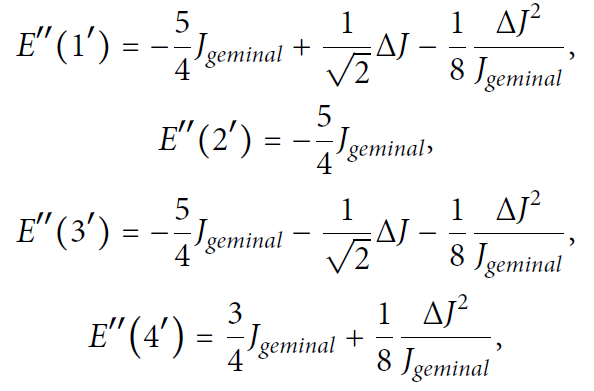

In [15]:
# Symbolic asymptotics along DeltaJAM_ratio = DeltaJMX_ratio

if "formulas_2d" not in globals():
    raise RuntimeError("Run the symbolic extraction cell before evaluating asymptotics.")

delta = sp.symbols('delta', real=True)
sym_asymptotics = []

for model_key, outputs in formulas_2d.items():
    print(f"\nModel block: {model_key}")
    print("=" * 60)
    for output_name, expr in outputs.items():
        sym_expr = sp.sympify(expr)
        diag_expr = sp.simplify(sym_expr.subs({
            sp.Symbol('DeltaJAM_ratio'): delta,
            sp.Symbol('DeltaJMX_ratio'): delta
        }))
        series_diag = sp.series(diag_expr, delta, 0, 3)
        intercept = sp.N(diag_expr.subs(delta, 0))
        slope = sp.N(sp.diff(diag_expr, delta).subs(delta, 0))
        sym_asymptotics.append({
            "model": model_key,
            "output": output_name,
            "diag_expr": diag_expr,
            "intercept": intercept,
            "slope": slope,
            "series": series_diag
        })
        print(f"{output_name} along diagonal:")
        print(f"  lambda(delta) = {diag_expr}")
        print(f"  Series up to O(delta^2): {series_diag}")
        print(f"  lambda(0) = {intercept:.6f}")
        print(f"  d lambda / d delta |_(0) = {slope:.6f}")
        if 'lambda_at_zero' in globals():
            eig_idx = int(''.join(filter(str.isdigit, output_name))) - 1
            est = float(intercept)
            true_val = float(lambda_at_zero[eig_idx])
            print(f"    Difference vs exact Hamiltonian: {est - true_val:+.6e}")
        if 'linear_terms' in globals():
            eig_idx = int(''.join(filter(str.isdigit, output_name))) - 1
            true_slope = float(linear_terms[eig_idx, 0])  # slope from numpy fit
            print(f"    Difference in slope vs exact: {float(slope) - true_slope:+.6e}")


Model block: single_model
eigenval_1 along diagonal:
  lambda(delta) = -0.019*delta**6 + 0.166*delta**4 + 0.005*delta**3 - 0.773*delta**2 - 0.014*delta - 1.415
  Series up to O(delta^2): -1.415 - 0.014*delta - 0.773*delta**2 + O(delta**3)
  lambda(0) = -1.415000
  d lambda / d delta |_(0) = -0.014000
eigenval_2 along diagonal:
  lambda(delta) = 0.02*delta**8 - 0.155*delta**6 - 0.007*delta**5 + 0.369*delta**4 + 0.012*delta**3 - 0.295*delta**2 - 0.006*delta - 1.23
  Series up to O(delta^2): -1.23 - 0.006*delta - 0.295*delta**2 + O(delta**3)
  lambda(0) = -1.230000
  d lambda / d delta |_(0) = -0.006000
eigenval_3 along diagonal:
  lambda(delta) = -0.01*delta**8 + 0.112*delta**6 + 0.004*delta**5 - 0.424*delta**4 - 0.014*delta**3 + 0.743*delta**2 + 0.013*delta - 1.101
  Series up to O(delta^2): -1.101 + 0.013*delta + 0.743*delta**2 + O(delta**3)
  lambda(0) = -1.101000
  d lambda / d delta |_(0) = 0.013000
eigenval_4 along diagonal:
  lambda(delta) = 0.004*delta**6 - 0.02*delta**4 + 0.26*

# Summary

This notebook successfully:

1. **Generated 2D dataset** using `ham_reduced_symmetric(Jintra, Jintra, Jintra, DeltaJAM, DeltaJMX, 0)`
2. **Normalized parameters** to create 2 input variables: DeltaJAM/Jintra and DeltaJMX/Jintra
3. **Visualized 2D eigenvalue surfaces** showing the complex parameter dependencies
4. **Trained a 2D KAN model** with architecture (2, 12, 8, 4) to predict 4 normalized eigenvalues
5. **Evaluated performance** with R² scores for each eigenvalue
6. **Compared surfaces** between true quantum mechanical calculations and KAN predictions
7. **Extracted symbolic formulas** showing the mathematical relationships learned by the KAN

The 2D KAN model demonstrates the ability to learn complex multi-dimensional quantum mechanical relationships from the reduced symmetric Hamiltonian, providing both accurate predictions and interpretable symbolic expressions.

Generating 2D dataset: 100%|██████████| 5000/5000 [00:00<00:00, 10854.32it/s]


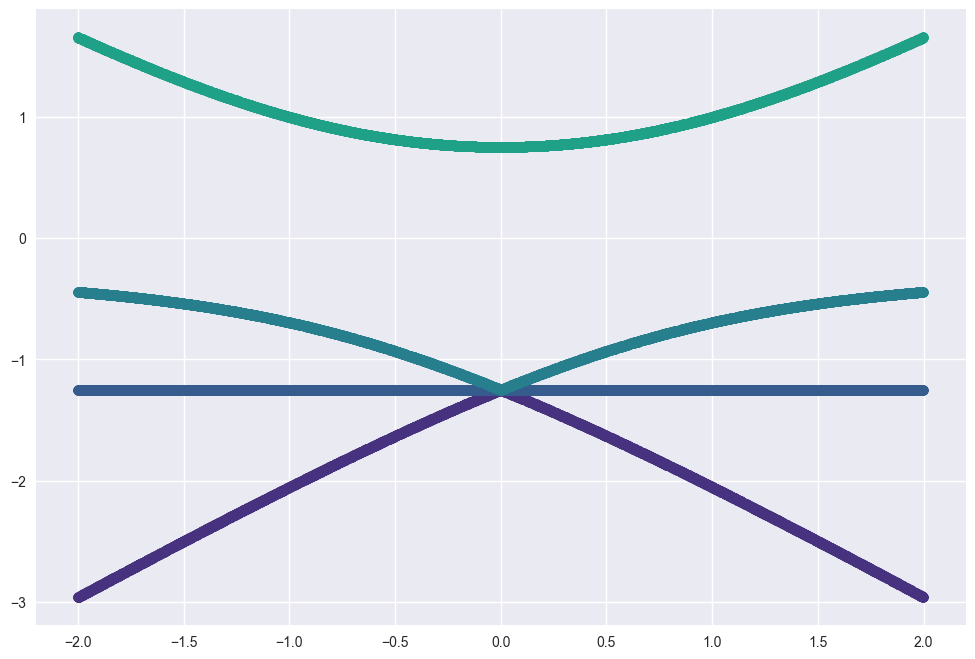

In [16]:
def generate_2d_normalized_dataset_diag(n_samples=5000, 
                                 deltajam_ratio_range=(-2.0, 2.0), 
                                 deltajmx_ratio_range=(-2.0, 2.0)):
    """
    Generate normalized 2D dataset using ham_reduced_symmetric.
    
    Directly generates ratios (DeltaJAM/Jintra, DeltaJMX/Jintra) uniformly,
    then calls ham_reduced_symmetric(1, 1, 1, ratio1, ratio2, 0).
    
    Parameters:
    - deltajam_ratio_range: Range for DeltaJAM/Jintra ratio
    - deltajmx_ratio_range: Range for DeltaJMX/Jintra ratio
    
    Returns normalized inputs (DeltaJAM/Jintra, DeltaJMX/Jintra) and normalized eigenvalues
    """
    
    # Generate random ratios directly (uniformly distributed)
    np.random.seed(42)  # For reproducibility
    deltajam_ratios = np.random.uniform(deltajam_ratio_range[0], deltajam_ratio_range[1], n_samples)
    deltajmx_ratios = deltajam_ratios
    #deltajmx_ratios = np.random.uniform(deltajmx_ratio_range[0], deltajmx_ratio_range[1], n_samples)
    
    # Initialize output arrays
    inputs_normalized = np.zeros((n_samples, 2))
    eigenvals_normalized = np.zeros((n_samples, 4))  # 4x4 Hamiltonian has 4 eigenvalues
    
    successful_samples = 0
    
    for i in tqdm(range(n_samples), desc="Generating 2D dataset"):
        try:
            # Use ratios directly
            deltajam_ratio = deltajam_ratios[i]
            deltajmx_ratio = deltajmx_ratios[i]
            
            # Create Hamiltonian: ham_reduced_symmetric(JAA, JMM, JXX, dJAM, dJMX, dJAX)
            # We use: JAA=JMM=JXX=1 (normalized), dJAM=deltajam_ratio, dJMX=deltajmx_ratio, dJAX=0
            H = ham_reduced_symmetric(1.0, 1.0, 1.0, deltajam_ratio, deltajmx_ratio, 0.0)
            
            # Calculate eigenvalues (already normalized since Jintra=1)
            eigenvals, _ = eigh(H)
            eigenvals = sort_eigenvalues_with_flip(eigenvals, ratio_value=deltajam_ratio*0+1)
            # Store inputs (ratios)
            inputs_normalized[successful_samples, 0] = deltajam_ratio
            inputs_normalized[successful_samples, 1] = deltajmx_ratio
            
            # Store eigenvalues (already normalized)
            eigenvals_normalized[successful_samples, :] = eigenvals
            
            successful_samples += 1
            
        except Exception as e:
            continue
    
    # Trim arrays to successful samples
    inputs_final = inputs_normalized[:successful_samples]
    eigenvals_final = eigenvals_normalized[:successful_samples]
    
    return inputs_final, eigenvals_final
dataset=generate_2d_normalized_dataset_diag()
plt.scatter(dataset[0][:,0], dataset[1][:,0])
plt.scatter(dataset[0][:,0], dataset[1][:,1])
plt.scatter(dataset[0][:,0], dataset[1][:,2])
plt.scatter(dataset[0][:,0], dataset[1][:,3])